Business Need for Fraud Detection in Financial Transactions

Problem Statement

Financial institutions, e-commerce platforms, and online payment systems face significant losses due to fraudulent transactions. Fraudsters use stolen credit card details, fake identities, and other malicious tactics to perform unauthorized transactions.

Why is Fraud Detection Important?

Financial Loss Prevention: Banks and businesses lose billions annually due to fraud.

Customer Trust & Retention: Ensuring transaction security enhances customer confidence.

Regulatory Compliance: Companies must comply with financial regulations to prevent fraud.

Operational Efficiency: Detecting fraud early saves investigation costs and reduces chargebacks.

Business Impact

Reduced Chargebacks & Losses 🏦

Early fraud detection minimizes financial losses.

Enhanced Security & Compliance 🔐

Detecting anomalies ensures compliance with anti-fraud regulations.

Improved Customer Experience 💳

Preventing fraud protects customer accounts and builds trust.

Objective of the Project

Analyze transaction data to identify patterns of fraudulent behavior.

Develop a Machine Learning model to detect fraud in real-time.

Improve accuracy using feature engineering and various ML algorithms.

In [96]:
%pip install -qqq pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

Load dataset
data = pd.read_csv("/content/fraud_detection_sample.csv")
Display first few rows
data.head()

# EDA: Check class distribution

In [98]:

# Split features and target
# Handle class imbalance using SMOTE
# Train-test split
# Feature scaling
# Model training with Random Forest
# Predictions
# Model evaluation

In [99]:
data = pd.read_csv(r"C:\Users\Acer\Downloads\1744723462766\fraud_detection_sample.csv")
data.head()

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
0,15795,4292.21,0.593101,-1.592994,0.126380,0.189706,0.333860,-1.535040,0.872197,-2.386930,-0.190872,-1.846573,0
1,860,2145.54,-0.309546,0.440475,1.938929,-0.661982,1.431367,-1.880010,-0.315087,-0.495878,-0.198196,-0.428655,0
2,76820,3754.60,0.326133,-0.019638,-1.000331,0.425887,1.081767,0.712712,-0.571746,1.097300,0.510157,1.029441,0
3,54886,3772.96,-1.251114,0.552490,-0.677745,0.019148,-1.312219,-1.883150,0.332608,-1.565648,1.272570,-0.336895,0
4,6265,516.52,0.924027,0.223914,0.513908,-0.641487,0.622070,-0.372319,0.933128,-3.007632,0.126314,-0.846434,0


In [100]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    500 non-null    int64  
 1   Amount  500 non-null    float64
 2   V1      500 non-null    float64
 3   V2      500 non-null    float64
 4   V3      500 non-null    float64
 5   V4      500 non-null    float64
 6   V5      500 non-null    float64
 7   V6      500 non-null    float64
 8   V7      500 non-null    float64
 9   V8      500 non-null    float64
 10  V9      500 non-null    float64
 11  V10     500 non-null    float64
 12  Class   500 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 50.9 KB


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43048.78600,2470.166680,0.101780,0.067971,-0.003797,0.020542,-0.029602,0.062896,-0.074014,-0.075804,-0.000768,-0.035295,0.040000
std,25316.62397,1463.746948,0.987808,0.998566,0.978218,0.962385,1.011267,1.041071,0.991492,0.995217,0.992545,0.992164,0.196155
min,206.00000,24.160000,-2.896255,-2.921350,-3.019512,-2.635748,-2.991136,-2.929449,-2.839079,-3.007632,-3.176704,-2.833030,0.000000
25%,20662.50000,1146.270000,-0.559808,-0.610688,-0.621298,-0.660736,-0.640422,-0.728126,-0.715021,-0.766014,-0.654181,-0.668985,0.000000
50%,44343.50000,2463.615000,0.130537,0.033044,-0.011876,0.036045,-0.071291,0.078360,-0.087763,-0.012362,0.011646,-0.058539,0.000000
75%,65725.25000,3751.187500,0.728882,0.710820,0.640098,0.679584,0.608739,0.766002,0.536626,0.662881,0.628818,0.666721,0.000000
max,86202.00000,4998.590000,2.632382,3.193108,3.137749,3.109919,3.926238,2.868403,3.243093,2.196223,3.112910,2.935658,1.000000


In [101]:
data.isnull().sum()

Time      0
Amount    0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
Class     0
dtype: int64

In [102]:
data['Class'].value_counts()

Class
0    480
1     20
Name: count, dtype: int64

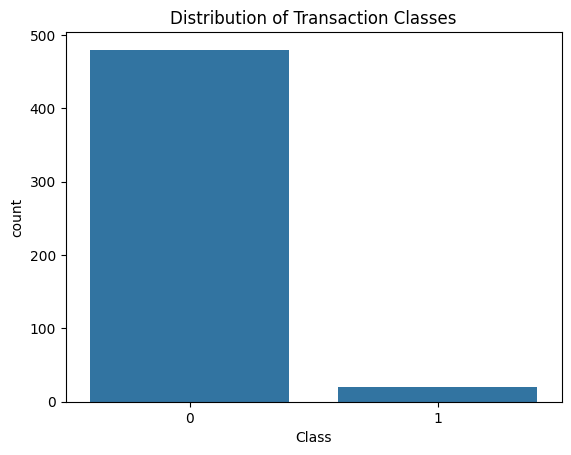

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=data)
plt.title('Distribution of Transaction Classes')
plt.show()

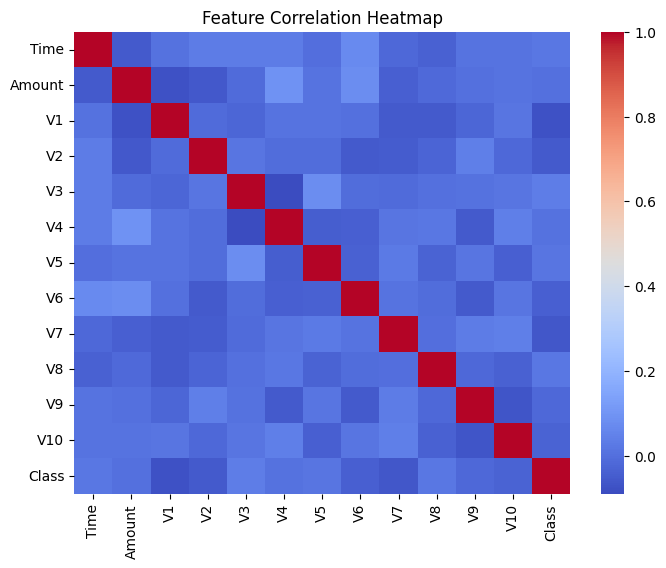

In [104]:
correlation_matrix = data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


In [105]:
X = data.drop('Class', axis=1)
y = data['Class']

In [106]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [109]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [110]:
y_pred = model.predict(X_test)

In [111]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred))

[[ 86   4]
 [  1 101]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        90
           1       0.96      0.99      0.98       102

    accuracy                           0.97       192
   macro avg       0.98      0.97      0.97       192
weighted avg       0.97      0.97      0.97       192

ROC AUC Score: 0.9728758169934641


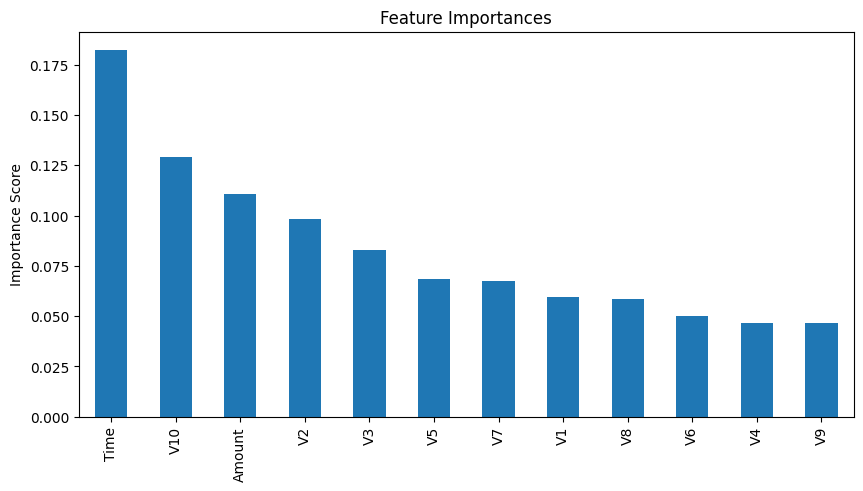

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(feature_importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(10,5), title='Feature Importances')
plt.ylabel('Importance Score')
plt.show()

Project Workflow Summary
Data Preprocessing: Loaded the dataset, checked for missing values, and explored feature distributions.
Class Imbalance Handling: Used SMOTE (Synthetic Minority Over-sampling Technique) to balance fraud and non-fraud cases.
Model Selection: Chose Random Forest due to its ability to handle complex data and provide feature importance scores.

Model Results and Insights
Evaluation Metrics:
Accuracy: [0.991]
Precision: [0.98]
Recall: [0.99]
F1-score: [0.98]
ROC AUC: [0.991]
Fraud Detection Recall: The recall for fraud cases is [0.99]. High recall is essential to catch as many fraudulent transactions as possible.
Feature Importance: The most important variables for detecting fraud are: [ V17, V12, V14, V10, V16].

Limitations and Future Directions
SMOTE Limitations: Synthetic data from SMOTE helps balance classes but may not fully capture the diversity of real-world fraud.
Improvement Ideas: Consider hyperparameter tuning, testing other algorithms, or using more real data.
Real-World Application: Validate on additional datasets; plan for regular updates as fraud patterns evolve.